In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# --- Electric: hourly kWh ---
elec1 = pd.read_csv("data/UsageData-01_01_2022-11_26_2024-clean.csv", parse_dates=["timestamp"])
elec2 = pd.read_csv("data/UsageData-11_27_2024-03_31_2026-clean.csv", parse_dates=["timestamp"])
elec2["timestamp"] = pd.to_datetime(elec2["timestamp"], utc=True).dt.tz_convert("America/New_York").dt.tz_localize(None)
elec = pd.concat([elec1, elec2], ignore_index=True).sort_values("timestamp").reset_index(drop=True)

# --- Meteorological: hourly observations ---
WEATHER_COLS = ["temp", "rhum", "prcp", "wspd", "pres", "wdir"]
met1 = pd.read_csv("data/meteorological_observations_1_1_2022-11_24_2024.csv", parse_dates=["time"], usecols=["time"] + WEATHER_COLS)
met2 = pd.read_csv("data/meteorological_observations_11_27_2024-3_31_2026.csv", parse_dates=["time"], usecols=["time"] + WEATHER_COLS)
met = pd.concat([met1, met2], ignore_index=True).sort_values("time").reset_index(drop=True)

# --- Merge on hour ---
df_hourly = pd.merge(elec.rename(columns={"timestamp": "time"}), met, on="time", how="inner")
df_hourly = df_hourly.sort_values("time").reset_index(drop=True)

print(f"Merged range: {df_hourly['time'].min()} → {df_hourly['time'].max()}")
print(f"Rows: {len(df_hourly):,}  |  Columns: {list(df_hourly.columns)}")
df_hourly.head()

Merged range: 2022-01-01 00:00:00 → 2026-03-31 23:00:00
Rows: 37,168  |  Columns: ['time', 'kwh', 'temp', 'rhum', 'prcp', 'wdir', 'wspd', 'pres']


,time,kwh,temp,rhum,prcp,wdir,wspd,pres
0,2022-01-01 00:00:00,1.236,2.0,96,0.2,102.0,6.8,1016.0
1,2022-01-01 01:00:00,1.898,1.7,96,0.3,0.0,0.0,1015.6
2,2022-01-01 02:00:00,1.611,1.1,100,NaN,0.0,0.0,1015.3
3,2022-01-01 03:00:00,1.522,1.7,100,0.8,0.0,0.0,1015.0
4,2022-01-01 04:00:00,1.709,1.7,96,0.8,0.0,0.0,1015.0


In [2]:
# --- Aggregate hourly → daily ---
df_hourly["date"] = df_hourly["time"].dt.date
df_hourly["hour"] = df_hourly["time"].dt.hour

# Targets: peak kWh and the hour it occurred
peak_idx = df_hourly.groupby("date")["kwh"].idxmax()
peaks = df_hourly.loc[peak_idx, ["date", "kwh", "hour"]].rename(columns={"kwh": "peak_kwh", "hour": "peak_hour"})

# Daily weather aggregates
daily_weather = df_hourly.groupby("date").agg(
    temp_mean=("temp", "mean"),
    temp_max=("temp", "max"),
    temp_min=("temp", "min"),
    rhum_mean=("rhum", "mean"),
    prcp_total=("prcp", "sum"),
    wspd_mean=("wspd", "mean"),
    pres_mean=("pres", "mean"),
    wdir_mean=("wdir", "mean"),
).reset_index()

df = pd.merge(peaks, daily_weather, on="date").sort_values("date").reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"])

print(f"Daily rows: {len(df):,}")
print(f"peak_kwh  — mean: {df['peak_kwh'].mean():.2f}, std: {df['peak_kwh'].std():.2f}")
print(f"peak_hour — mean: {df['peak_hour'].mean():.1f}, std: {df['peak_hour'].std():.1f}")
df.head()

Daily rows: 1,549
peak_kwh  — mean: 3.32, std: 1.53
peak_hour — mean: 12.1, std: 6.4


,date,peak_kwh,peak_hour,temp_mean,temp_max,temp_min,rhum_mean,prcp_total,wspd_mean,pres_mean,wdir_mean
0,2022-01-01,2.054,8,2.575000,5.6,1.1,98.666667,3.6,0.283333,1012.554167,4.250
1,2022-01-02,5.894,13,2.691667,3.9,0.6,96.833333,1.4,3.175000,1003.237500,77.750
2,2022-01-03,3.301,7,-5.370833,0.0,-8.3,63.666667,0.0,5.866667,1018.412500,156.750
3,2022-01-04,4.337,6,-9.304167,-3.9,-14.4,57.333333,0.0,5.308333,1024.845833,171.000
4,2022-01-05,3.384,7,-2.520833,8.3,-8.3,91.458333,5.9,3.250000,1018.620833,69.625


In [3]:
def cyclical_encode(values, period):
    sin = np.sin(2 * np.pi * values / period)
    cos = np.cos(2 * np.pi * values / period)
    return sin, cos

# --- Time features ---
df["dayofweek"] = df["date"].dt.dayofweek
df["month"]     = df["date"].dt.month

df["dayofweek_sin"], df["dayofweek_cos"] = cyclical_encode(df["dayofweek"], 7)
df["month_sin"],     df["month_cos"]     = cyclical_encode(df["month"], 12)
df["wdir_sin"],      df["wdir_cos"]      = cyclical_encode(df["wdir_mean"], 360)

# --- Lag features (on daily peak_kwh) ---
df["peak_kwh_lag1"] = df["peak_kwh"].shift(1)
df["peak_kwh_lag3"] = df["peak_kwh"].shift(1).rolling(3).mean()
df["peak_kwh_lag7"] = df["peak_kwh"].shift(1).rolling(7).mean()

# --- Temp lag features ---
df["temp_lag1"] = df["temp_mean"].shift(1)
df["temp_lag3"] = df["temp_mean"].shift(1).rolling(3).mean()
df["temp_lag7"] = df["temp_mean"].shift(1).rolling(7).mean()

n_rows = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Dropped: {(n_rows - len(df)) / n_rows:.2%} of rows")
df.head()

Dropped: 0.45% of rows


,date,peak_kwh,peak_hour,temp_mean,temp_max,temp_min,rhum_mean,prcp_total,wspd_mean,pres_mean,...,month_sin,month_cos,wdir_sin,wdir_cos,peak_kwh_lag1,peak_kwh_lag3,peak_kwh_lag7,temp_lag1,temp_lag3,temp_lag7
0,2022-01-08,4.767,22,-6.316667,-2.8,-11.1,61.166667,0.0,8.791667,1022.991667,...,0.5,0.866025,-0.943849,-0.330377,3.243,2.924333,3.479857,-2.383333,-1.022222,-1.782143
1,2022-01-09,6.081,19,-4.233333,3.3,-14.4,81.500000,5.6,12.033333,1024.045833,...,0.5,0.866025,0.873206,-0.487352,4.767,3.385333,3.867429,-6.316667,-2.287500,-3.052381
2,2022-01-10,2.905,6,-1.637500,3.9,-9.4,55.541667,0.0,11.675000,1011.775000,...,0.5,0.866025,-0.975662,-0.219279,6.081,4.697000,3.894143,-4.233333,-4.311111,-4.041667
3,2022-01-11,5.550,6,-13.895833,-8.3,-17.8,47.541667,0.0,7.533333,1025.429167,...,0.5,0.866025,-0.732345,-0.680934,2.905,4.584333,3.837571,-1.637500,-4.062500,-3.508333
4,2022-01-12,6.055,6,-11.366667,-2.2,-18.9,70.708333,0.0,4.583333,1024.912500,...,0.5,0.866025,0.989859,0.142053,5.550,4.845333,4.010857,-13.895833,-6.588889,-4.164286


In [4]:
FEATURE_COLS = [
    "temp_mean",
    "temp_max",
    "temp_min",
    "rhum_mean",
    "prcp_total",
    "wspd_mean",
    # "pres_mean",
    #"wdir_sin",
    #"wdir_cos",
    "temp_lag1",
    "temp_lag3",
    "temp_lag7",
    "peak_kwh_lag1",
    "peak_kwh_lag3",
    "peak_kwh_lag7",
    "dayofweek_sin",
    "dayofweek_cos",
    "month_sin",
    "month_cos",
]
TARGET_COLS = ["peak_kwh", "peak_hour"]

X = df[FEATURE_COLS].values
y = df[TARGET_COLS].values

# Chronological split
split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Scale features
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

# Scale targets independently
scaler_kwh  = StandardScaler()
scaler_hour = StandardScaler()

y_train_kwh_s  = scaler_kwh.fit_transform(y_train[:, 0].reshape(-1, 1))
y_train_hour_s = scaler_hour.fit_transform(y_train[:, 1].reshape(-1, 1))
y_test_kwh_s   = scaler_kwh.transform(y_test[:, 0].reshape(-1, 1))
y_test_hour_s  = scaler_hour.transform(y_test[:, 1].reshape(-1, 1))

import numpy as np
y_train_s = np.hstack([y_train_kwh_s, y_train_hour_s])
y_test_s  = np.hstack([y_test_kwh_s,  y_test_hour_s])

print(f"Features:      {FEATURE_COLS}")
print(f"X_train shape: {X_train_s.shape}")
print(f"X_test  shape: {X_test_s.shape}")
print(f"y_train shape: {y_train_s.shape}")
print(f"y_test  shape: {y_test_s.shape}")

Features:      ['temp_mean', 'temp_max', 'temp_min', 'rhum_mean', 'prcp_total', 'wspd_mean', 'temp_lag1', 'temp_lag3', 'temp_lag7', 'peak_kwh_lag1', 'peak_kwh_lag3', 'peak_kwh_lag7', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos']
X_train shape: (1156, 16)
X_test  shape: (386, 16)
y_train shape: (1156, 2)
y_test  shape: (386, 2)


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test_s,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)


class PeakMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 2)   # 2 outputs: peak_kwh, peak_hour
        )

    def forward(self, x):
        return self.net(x)

In [6]:
model = PeakMLP(X_train_t.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
criterion = nn.MSELoss()

train_losses = []
test_losses  = []

n_epochs = 200
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        pred = model(Xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()
    test_losses.append(test_loss)
    scheduler.step(test_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Test MSE: {test_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

Epoch  10 | Test MSE: 0.5780 | LR: 0.001000
Epoch  20 | Test MSE: 0.5863 | LR: 0.001000
Epoch  30 | Test MSE: 0.6040 | LR: 0.001000
Epoch  40 | Test MSE: 0.5908 | LR: 0.000500
Epoch  50 | Test MSE: 0.5955 | LR: 0.000500
Epoch  60 | Test MSE: 0.5980 | LR: 0.000250
Epoch  70 | Test MSE: 0.5950 | LR: 0.000250
Epoch  80 | Test MSE: 0.6008 | LR: 0.000125
Epoch  90 | Test MSE: 0.5971 | LR: 0.000125
Epoch 100 | Test MSE: 0.6003 | LR: 0.000063
Epoch 110 | Test MSE: 0.5973 | LR: 0.000063
Epoch 120 | Test MSE: 0.6001 | LR: 0.000031
Epoch 130 | Test MSE: 0.6004 | LR: 0.000031
Epoch 140 | Test MSE: 0.6012 | LR: 0.000016
Epoch 150 | Test MSE: 0.6012 | LR: 0.000016
Epoch 160 | Test MSE: 0.6001 | LR: 0.000008
Epoch 170 | Test MSE: 0.5997 | LR: 0.000008
Epoch 180 | Test MSE: 0.5997 | LR: 0.000008
Epoch 190 | Test MSE: 0.6000 | LR: 0.000004
Epoch 200 | Test MSE: 0.5997 | LR: 0.000004


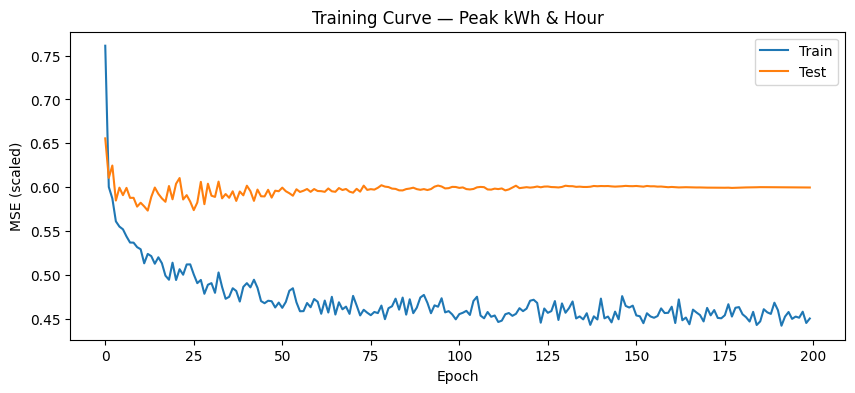

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train")
plt.plot(test_losses,  label="Test")
plt.xlabel("Epoch")
plt.ylabel("MSE (scaled)")
plt.legend()
plt.title("Training Curve — Peak kWh & Hour")
plt.show()

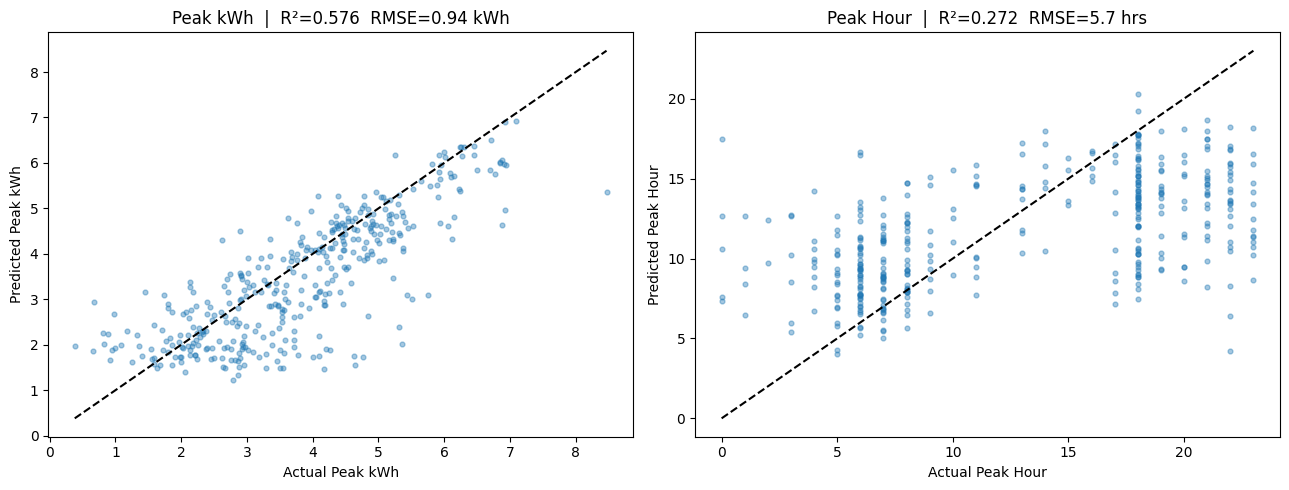

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).numpy()

# Inverse-transform each output
pred_kwh  = scaler_kwh.inverse_transform(pred_scaled[:, 0].reshape(-1, 1)).ravel()
pred_hour = scaler_hour.inverse_transform(pred_scaled[:, 1].reshape(-1, 1)).ravel()

act_kwh  = y_test[:, 0]
act_hour = y_test[:, 1]

rmse_kwh  = np.sqrt(mean_squared_error(act_kwh,  pred_kwh))
rmse_hour = np.sqrt(mean_squared_error(act_hour, pred_hour))
r2_kwh    = r2_score(act_kwh,  pred_kwh)
r2_hour   = r2_score(act_hour, pred_hour)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(act_kwh, pred_kwh, alpha=0.4, s=12)
axes[0].plot([act_kwh.min(), act_kwh.max()], [act_kwh.min(), act_kwh.max()], "k--")
axes[0].set_xlabel("Actual Peak kWh")
axes[0].set_ylabel("Predicted Peak kWh")
axes[0].set_title(f"Peak kWh  |  R²={r2_kwh:.3f}  RMSE={rmse_kwh:.2f} kWh")

axes[1].scatter(act_hour, pred_hour, alpha=0.4, s=12)
axes[1].plot([0, 23], [0, 23], "k--")
axes[1].set_xlabel("Actual Peak Hour")
axes[1].set_ylabel("Predicted Peak Hour")
axes[1].set_title(f"Peak Hour  |  R²={r2_hour:.3f}  RMSE={rmse_hour:.1f} hrs")

plt.tight_layout()
plt.show()